# Retail Sales Analytics using Python

## Objective

Analyze retail sales data to identify business trends,
top-performing categories, profitable regions,
and the impact of discounts on profit.

In [8]:
import pandas as pd

df = pd.read_csv("./data/SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [9]:
df.shape

(9994, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [11]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [12]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [13]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(17)

In [15]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(9977, 13)

In [19]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

Total Sales: 2296195.5903
Total Profit: 286241.42260000005


In [20]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64

In [21]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64

In [23]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=True)

Region
South      391721.9050
Central    500782.8528
East       678435.1960
West       725255.6365
Name: Sales, dtype: float64

In [24]:
df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91683.0240
Paper           78224.1420
Supplies        46673.5380
Art             27107.0320
Envelopes       16476.4020
Labels          12444.9120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [38]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
avg_discount = df["Discount"].mean()

print("📊 KPI SUMMARY")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Average Discount: {avg_discount:.2%}")

📊 KPI SUMMARY
Total Sales: $2,296,195.59
Total Profit: $286,241.42
Total Quantity Sold: 37820
Average Discount: 15.63%


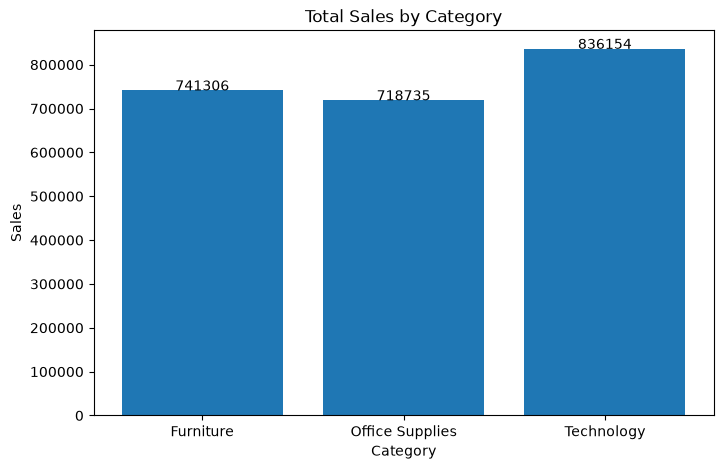

In [46]:
import matplotlib.pyplot as plt

# Calculate total sales by category
category_sales = df.groupby("Category")["Sales"].sum()

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)

# Add title and labels
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

# Display values on top of bars
for i, value in enumerate(category_sales.values):
    plt.text(i, value, f"{value:.0f}", ha='center')

plt.savefig("images/sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

- Technology generated the highest sales.
- Office Supplies performed consistently.
- Furniture generated the lowest sales.

### Recommendation

Increase investment in Technology products and improve promotional strategies for Furniture to boost sales.

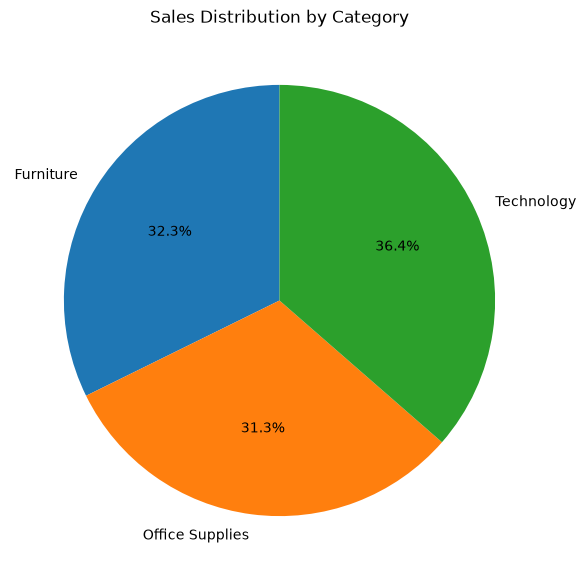

In [47]:
plt.figure(figsize=(7,7))
plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Category")
plt.savefig("images/sales_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

- Technology contributes the largest share of total sales.
- Office Supplies account for a significant portion of sales.
- Furniture contributes the smallest share of overall sales.

### Recommendation

- Continue investing in the Technology category as it generates the highest share of sales.
- Improve marketing strategies and promotional offers for the Furniture category to increase its market share.
- Maintain inventory levels for Office Supplies to meet consistent customer demand.

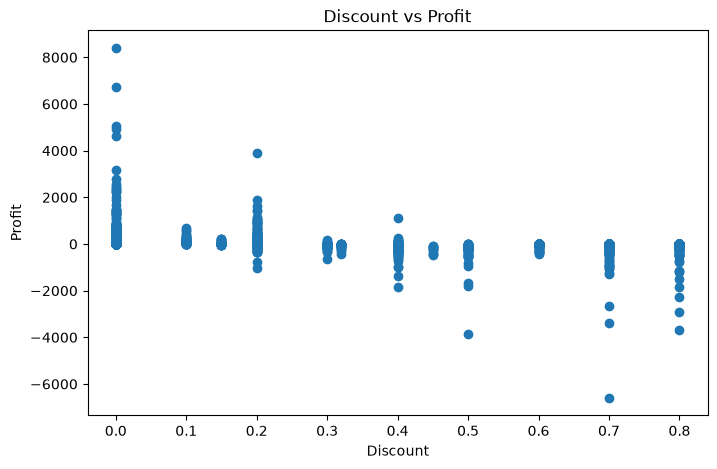

In [52]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.savefig("images/discount_vs_profit.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Higher discounts are often associated with lower profits.

### Recommendation

Avoid offering excessive discounts unless they significantly increase sales volume.

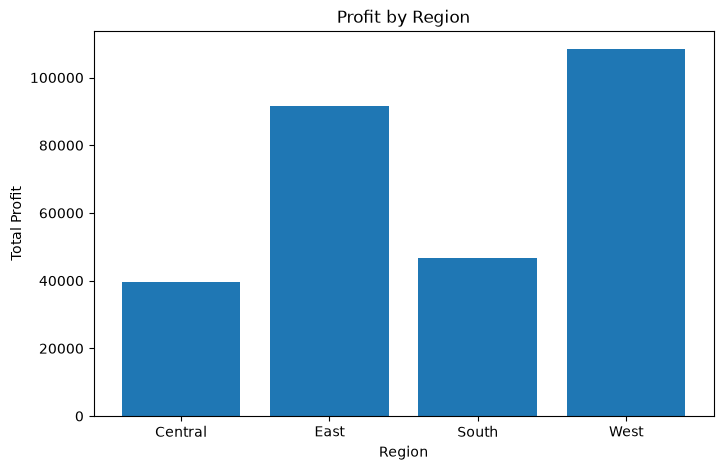

In [48]:
import matplotlib.pyplot as plt

region_profit = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(region_profit.index, region_profit.values)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.savefig("images/profit_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

- The West region generated the highest profit.
- The South region generated the lowest profit.

### Business Recommendation

Focus on improving sales strategies in low-profit regions while maintaining strong performance in high-profit regions.

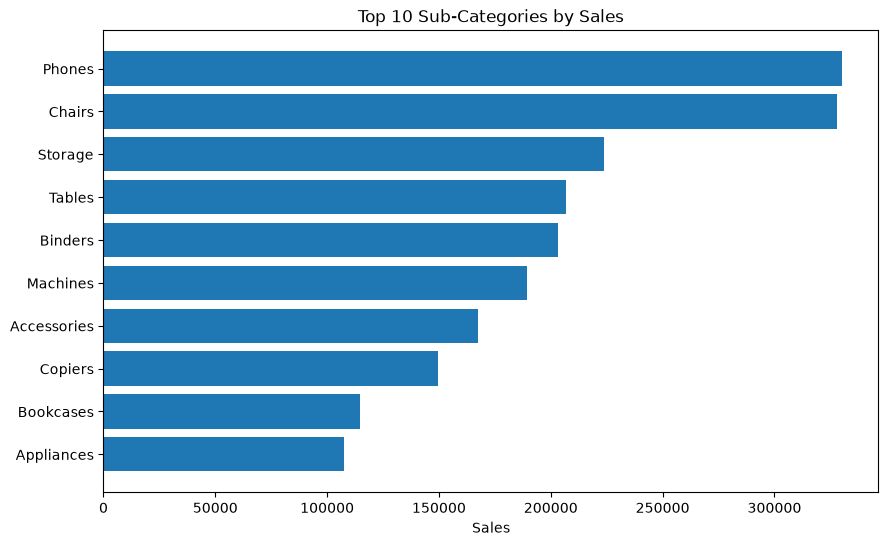

In [49]:
top_sub = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(top_sub.index, top_sub.values)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sales")

plt.gca().invert_yaxis()
plt.savefig("images/top_subcategories.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

- The top-ranked sub-category contributes significantly to total sales.
- Some sub-categories generate much lower sales than others.

### Business Recommendation

Increase inventory and marketing for top-performing sub-categories while evaluating strategies to improve lower-performing ones.

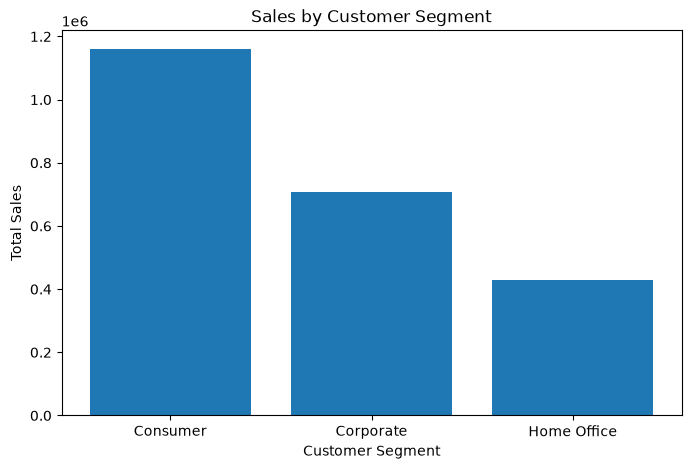

In [50]:
segment_sales = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(segment_sales.index, segment_sales.values)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.savefig("images/sales_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

- The Consumer segment contributes the highest sales.
- Corporate and Home Office segments contribute a smaller share.

### Business Recommendation

Continue focusing on Consumer customers while creating targeted promotions to increase sales in other segments.

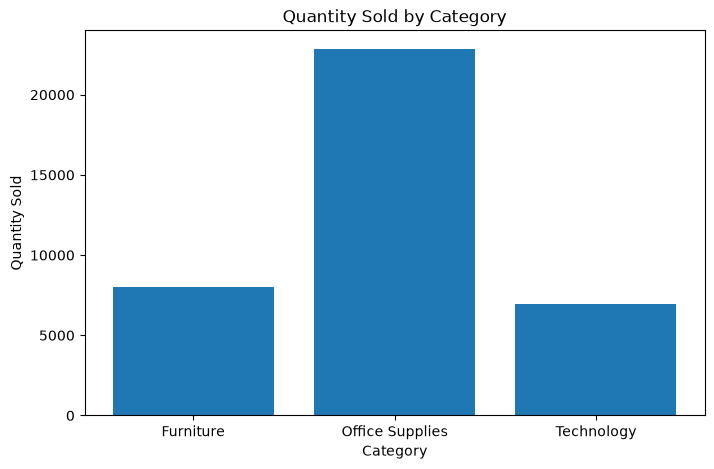

In [51]:
quantity = df.groupby("Category")["Quantity"].sum()

plt.figure(figsize=(8,5))
plt.bar(quantity.index, quantity.values)

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.savefig("images/quantity_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

- One category records the highest quantity sold.
- Customer demand differs across product categories.

### Business Recommendation

Ensure sufficient inventory for high-demand categories and review stocking strategies for categories with lower demand.

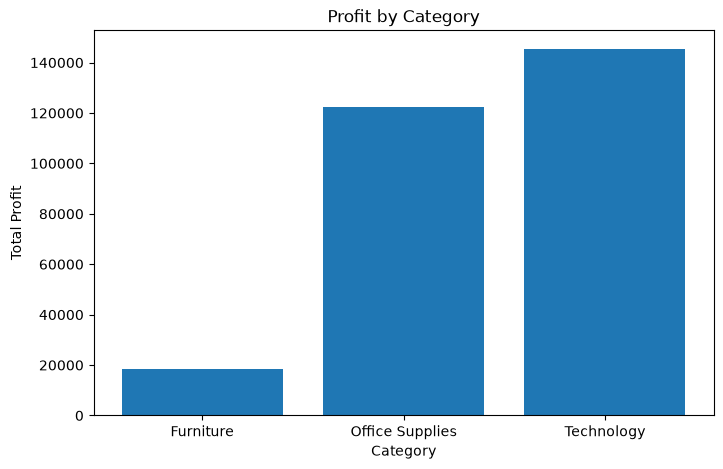

In [ ]:
profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(profit_category.index, profit_category.values)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

### Insight

- Profit differs across product categories.
- High sales do not always result in high profits.

### Business Recommendation

Focus on categories that generate both strong sales and strong profits. Review pricing and discount strategies for lower-profit categories.

📊 KPI SUMMARY
Total Sales: $2,296,195.59
Total Profit: $286,241.42
Total Quantity Sold: 37820
Average Discount: 15.63%

## Conclusion

This project analyzed retail sales data using Python, Pandas, and Matplotlib.

The analysis identified top-performing categories, customer segments, regional performance, and the impact of discounts on profitability.

These insights can help businesses make better decisions related to pricing, inventory management, and marketing.